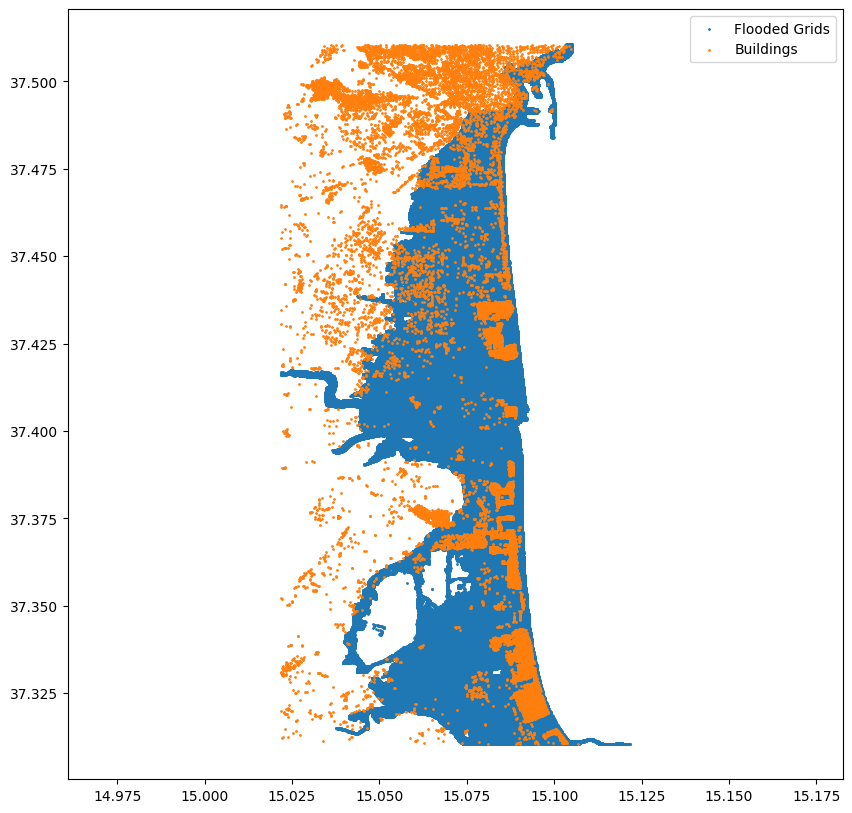

HDF5 file created successfully


In [4]:
import os
import sys
# import geopandas as gpd
import pandas as pd
import numpy as np
import h5py
import matplotlib.pyplot as plt
from openquake.hazardlib import site
from openquake.baselib import hdf5

#read geopackage file with building polygons
haz_path = '/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/data/processed/lat_lon_idx_CT_892.txt'
ex_path = '/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/risk/loss/building_exposure.csv'
flooded_grids = pd.read_csv(haz_path, sep=',', header=None)
building_exposure = pd.read_csv(ex_path, sep=',')

flooded_grids.columns = ['m', 'n', 'lat', 'lon']

#plot the flooded grids
plt.figure(figsize=(10,10))
plt.scatter(flooded_grids['lon'], flooded_grids['lat'], s=1,label='Flooded Grids')
plt.scatter(building_exposure['Lon'], building_exposure['Lat'], s=1, label='Buildings')
plt.legend()
plt.axis('equal')
plt.show()

#save hazard as lat,lon,intensity
flooded_grids['intensity'] = 3
flooded_grids = flooded_grids[['lat', 'lon', 'intensity']]

#save calculation locations as lat,lon
sites = flooded_grids[['lon', 'lat']]
sites.to_csv('/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/risk/demos/tsunamiscenario_imt/tsunami_sites.csv', sep=',', header=None, index=None)

#save tsunami scenario with depth per site info as rlzi,sid,eid,gmv_PGA
rlzi = 0
sid = np.arange(0, len(sites))
eid = 0
FLOWDEPTH = 3

tsunami_scenario = pd.DataFrame({'rlzi': rlzi, 'sid': sid, 'eid': eid, 'FLOWDEPTH': FLOWDEPTH})
tsunami_scenario.to_csv('//mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/risk/demos/tsunamiscenario_imt/tsunami_scenario.csv', sep=',', header=True, index=None)

#prepare hdf5 file with gmf_data and sitecol as groups
hdf5_file = '//mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/risk/demos/tsunamiscenario_imt/tsunami_scenario.hdf5'

# site collection
haz_sitecol = site.SiteCollection.from_points(sites['lon'], sites['lat'],req_site_params = {})

with hdf5.File(hdf5_file, 'w') as hf:
    hf.create_group('gmf_data')
    hf.create_dataset('gmf_data/sid', data=tsunami_scenario['sid'],dtype='uint32')
    hf.create_dataset('gmf_data/eid', data=tsunami_scenario['eid'], dtype='uint32')
    hf.create_dataset('gmf_data/FLOWDEPTH', data=tsunami_scenario['FLOWDEPTH'], dtype='float32')
    hf['gmf_data'].attrs['__pdcolumns__'] = 'sid eid FLOWDEPTH'
    hf['gmf_data'].attrs['imts'] = 'FLOWDEPTH'
    hf['gmf_data'].attrs['num_events'] = 1
    hf['gmf_data'].attrs['investigation_time'] = 1
    hf['gmf_data'].attrs['effective_time'] = 1
    hf.create_group('sitecol')
    hf['sitecol'] = haz_sitecol
    hf.close()
print('HDF5 file created successfully')